<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 1

Numa roseta de extensómetros são obtidas leituras em direções fazendo ângulos de 120 $^\circ$ entre si, como representado na Figura. Sabe-se que $\varepsilon_a = 600 \times 10^{-6}$, $\varepsilon_b = 300 \times 10^{-6}$ e $\varepsilon_c = 150 \times 10^{-6}$.

(a) Escolha um referencial e indique o tensor das extensões a ele associado.

(b) Analise as deformações principais e as direções principais, bem como a distorção angular máxima/mínima.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P001_i1.jpg"
width="300" height="280">

## Resolução

### a) Escolha um referencial e indique o tensor das extensões a ele associado.

A medição da extensão linear numa determinada direção ($\bar{AB}$), definida por um ângulo $\theta$ em relação ao eixo horizontal é dada pela seguinte lei de transformação:

\begin{equation*}
\begin{aligned}
\varepsilon_\mathrm{AB} \equiv \varepsilon(\theta) &=
\varepsilon_{xx}\cos^2\theta + \varepsilon_{yy}\sin^2\theta + 2\varepsilon_{xy}\sin\theta\cos\theta \\
&=
\varepsilon_{xx}\cos^2\theta + \varepsilon_{yy}\sin^2\theta + \gamma_{xy}\sin\theta\cos\theta \\
\end{aligned}
\end{equation*}

Esta expressão de transformação permite determinar a extensão linear em qualquer direção, definida pelo ângulo $\theta$, conhecidas as três componentes cartesianas independentes do tensor das deformações no plano $x-y$.

Atendendo as relações trigonométricas:

- $\sin2\theta/2 = \sin\theta\cos\theta$
- $\cos^2\theta = (\cos2\theta + 1)/2$
- $\sin^2\theta = (1-\cos2\theta)/2$

A expressão anterior pode ser reescrita em função do ângulo $2\theta$ (método da circunferência de Mohr):

\begin{equation*}
\begin{aligned}
\varepsilon(\theta) &=
\frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} +
\frac{\varepsilon_{xx} - \varepsilon_{yy}}{2}\cos2\theta
+ \frac{\gamma_{xy}}{2} \sin2\theta \\
\end{aligned}
\end{equation*}

De notar portanto que uma única medição de extensão linear, numa determinada direção, obtida recorrendo por exemplo a um extensómetro é necessária mas não é suficiente para caraterizar completamente o estado de deformação num ponto material.

É posssível contudo obter um sistema de equações recorrendo a rosetas de três elementos, com ângulos de orientação distintos: $\theta_\mathrm{A},\theta_\mathrm{B},\theta_\mathrm{C}$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P001_i2.jpg"
width="400" height="260">

As equações de transformação associadas à roseta de três elementos enunciada, podem ser agrupadas no seguinte sistema de equações:

\begin{equation*}
\begin{cases}
\varepsilon_\mathrm{A} \equiv \varepsilon (\theta_\mathrm{A}) & =
\varepsilon_{xx}\cos^2\theta_{\mathrm{A}} + \varepsilon_{yy}\sin^2\theta_\mathrm{A} +
\gamma_{xy}\sin\theta_\mathrm{A}\cos\theta_\mathrm{A} \\
\varepsilon_\mathrm{B} \equiv \varepsilon (\theta_\mathrm{B}) & =
\varepsilon_{xx}\cos^2\theta_\mathrm{B} + \varepsilon_{yy}\sin^2\theta_\mathrm{B} +
\gamma_{xy}\sin\theta_\mathrm{B}\cos\theta_\mathrm{B} \\
\varepsilon_\mathrm{C} \equiv \varepsilon (\theta_\mathrm{C}) & =
\varepsilon_{xx}\cos^2\theta_\mathrm{C} + \varepsilon_{yy}\sin^2\theta_\mathrm{C} +
\gamma_{xy}\sin\theta_\mathrm{C}\cos\theta_\mathrm{C}
\end{cases}
\end{equation*}

In [12]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

epsa = 600e-6
ta = np.deg2rad(270)
# ou: ta = np.deg2rad(-90)
epsb = 300e-6
tb = np.deg2rad(150)

epsc = 150e-6
tc = np.deg2rad(30)

print('----------------------')
print('CALC 1 ')
print('----------------------')
epsxx,epsyy,gammaxy = symbols('epsxx epsyy gammaxy')

def extensometro(epsxx,epsyy,gammaxy,t):
    return epsxx*sy.cos(t)**2 + epsyy*sy.sin(t)**2 + gammaxy*sy.sin(t)*sy.cos(t)

print('\nSistema de equações:')
eq1 = epsa-extensometro(epsxx,epsyy,gammaxy,ta); print(eq1,' = 0')
eq2 = epsb-extensometro(epsxx,epsyy,gammaxy,tb); print(eq2,' = 0')
eq3 = epsc-extensometro(epsxx,epsyy,gammaxy,tc); print(eq3,' = 0')
CompDef = solve([eq1,eq2,eq3], [epsxx,epsyy,gammaxy], dict=True)
epsXX = float(CompDef[0][epsxx])
print('\nEstado de deformação:')
print('epsXX = ','{:.5e}'.format(epsXX))
epsYY = float(CompDef[0][epsyy])
print('epsYY = ','{:.5e}'.format(epsYY))
gamXY = float(CompDef[0][gammaxy])
print('gamXY = ','{:.5e}'.format(gamXY))
epsXY = gamXY/2
print('epsXY = gamXY/2 = ','{:.5e}'.format(epsXY))

matDef = np.array([[epsXX*1e6,epsXY*1e6],[epsXY*1e6,epsYY*1e6]])
print('\nMatriz das deformações (plano) = \n',matDef)

----------------------
CALC 1 
----------------------

Sistema de equações:
-3.37445951098918e-32*epsxx - 1.0*epsyy - 1.83697019872103e-16*gammaxy + 0.0006  = 0
-0.75*epsxx - 0.25*epsyy + 0.433012701892219*gammaxy + 0.0003  = 0
-0.75*epsxx - 0.25*epsyy - 0.433012701892219*gammaxy + 0.00015  = 0

Estado de deformação:
epsXX =  1.00000e-04
epsYY =  6.00000e-04
gamXY =  -1.73205e-04
epsXY = gamXY/2 =  -8.66025e-05

Matriz das deformações (plano) = 
 [[100.    -86.603]
 [-86.603 600.   ]]


Para a solução do sistema de equações, este pode ser convenientemente reformulado em notação matricial por:

\begin{equation*}
\begin{bmatrix}
\cos^2\theta_{\mathrm{A}} & \sin^2\theta_\mathrm{A} & \sin\theta_\mathrm{A}\cos\theta_\mathrm{A} \\
\cos^2\theta_{\mathrm{B}} & \sin^2\theta_\mathrm{B} & \sin\theta_\mathrm{B}\cos\theta_\mathrm{B} \\
\cos^2\theta_{\mathrm{C}} & \sin^2\theta_\mathrm{C} & \sin\theta_\mathrm{C}\cos\theta_\mathrm{C}
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{xx} \\
\varepsilon_{yy} \\
\gamma_{xy}
\end{bmatrix}=
\begin{bmatrix}
\varepsilon_\mathrm{A} \\
\varepsilon_\mathrm{B} \\
\varepsilon_\mathrm{C}
\end{bmatrix}
\end{equation*}

In [13]:
def CoefMat3roset(t1,t2,t3):
    return np.array([[np.cos(t1)**2, np.sin(t1)**2, np.cos(t1)*np.sin(t1)],
                     [np.cos(t2)**2, np.sin(t2)**2, np.cos(t2)*np.sin(t2)],
                     [np.cos(t3)**2, np.sin(t3)**2, np.cos(t3)*np.sin(t3)]])

ext3r = np.array([epsa,epsb,epsc])
estadodef2 = np.dot(np.linalg.inv(CoefMat3roset(ta,tb,tc)),ext3r)

np.set_printoptions(precision=4,suppress=True)
print('CoefMat3roset(ta,tb,tc) = \n', CoefMat3roset(ta,tb,tc))

np.set_printoptions(precision=5,suppress=False)
print('\nComponentes cartesianas do estado de def. =\n',estadodef2*1e6,' (micro def.)')

CoefMat3roset(ta,tb,tc) = 
 [[ 0.     1.     0.   ]
 [ 0.75   0.25  -0.433]
 [ 0.75   0.25   0.433]]

Componentes cartesianas do estado de def. =
 [ 100.       600.      -173.20508]  (micro def.)


Em resumo, o tensor das deformações vem dado por,

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}} \equiv \varepsilon_{ij} \equiv [\varepsilon] & =
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz} \\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \gamma_{zyy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{zyy}/2 & \varepsilon_{zz} \\
\end{bmatrix} \\
&=
\begin{bmatrix}
100. & -86.60 & 0 \\
-86.60 & 600. & 0 \\
0 & 0 & \varepsilon_{zz} \\
\end{bmatrix}~\mu\varepsilon
\end{aligned}
\end{equation*}

### b) Analise as deformações principais e as direções principais, bem como a distorção angular máxima/mínima.

**Deformações e direções principais**

As expressões já apresentadas, para o estado de tensão, para a determinação analítica das tensões principais e direções principais são válidas também para as deformações e direções principais no capítulo da análise do tensor das deformações. Nas equações de transformação, são válidas as seguintes relações de semelhança:

- $\sigma_{xx} ~\leftrightarrow~ \varepsilon_{xx} \quad|\quad \sigma_{yy} ~\leftrightarrow~ \varepsilon_{yy}
\quad|\quad \sigma_{zz} ~\leftrightarrow~ \varepsilon_{zz}$
- $\tau_{xy} ~\leftrightarrow~ \gamma_{xy}/2 \quad|\quad \tau_{yz} ~\leftrightarrow~ \gamma_{yz}/2
\quad|\quad \tau_{zx} ~\leftrightarrow~ \gamma_{zx}/2$

Atendendo ao facto de que as medições obtidas pelo extensómetro de três elementos ocorrerem na superfície plana do corpo (a extensão linear $\varepsilon_{zz}$ pode ser definida assumindo simplificações pelo estado plano de deformação ou estado plano de tensão; por exemplo, para um estado plano de deformação: $\varepsilon_{zz}=0$), as equações do círculo de Mohr podem ser usadas de forma expedita para a resolução do problema.

Atendendo às relações geométricas do método do círculo de Mohr, as extensões principais no plano $x-y$ podem ser determinadas em função das componentes cartesianas do tensor de deformação $(\varepsilon_{xx}, \varepsilon_{yy}, \gamma_{xy}$) (expressas num referencial $S_0$),
 pelas seguintes equações:

\begin{equation*}
\varepsilon_{\mathrm{P1,P2}} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \pm \sqrt{\left(\frac{\varepsilon_{xx} -
\varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

cujo centro e raio da circunferência vêm, respetivamente:

\begin{equation*}
\bar{\varepsilon} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \quad\wedge\quad R = \sqrt{\left(\frac{\varepsilon_{xx} -
\varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

Uma vez conhecidas as deformações principais é possível determinar as direções principais onde estas atuam. Para determinar os ângulos ou cosenos diretores associados às deformações principais, é possível usar uma expressão simples relacionando a dirtorção de corte ($\gamma_{xy}$) com as extensões normais ($\varepsilon_{xx}$, $\varepsilon_{yy}$):

\begin{equation*}
2\theta_\mathrm{P1} = \arctan\left(\frac{\gamma_{xy}}{\varepsilon_{xx} - \varepsilon_{yy}}\right)
\quad\wedge\quad
2\theta_\mathrm{P2} = 2\theta_\mathrm{P1} + 2(90^\circ)
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P001_i4.jpg" width="500" height="280">

In [14]:
def angP(e11,e22,g12): return np.arctan(g12/(e11-e22))

aP1 = angP(epsXX,epsYY,gamXY)
aP2 = aP1 + np.pi

print('direções principais (ângulos)')
print('\nNo espaço de Mohr:')
print(f'angPI  = {np.rad2deg(aP1):.1f} deg | {aP1:.3f} radians')
print(f'angPII = {np.rad2deg(aP2):.1f} deg | {aP2:.3f} radians')

aPI, aPII = aP1/2, aP2/2

print('\nNo espaço fisico:')
print(f'angPI  =  {np.rad2deg(aPI):.1f} deg | {aPI:.3f} radians')
print(f'angPII = {np.rad2deg(aPII):.1f} deg | {aPII:.3f} radians')


direções principais (ângulos)

No espaço de Mohr:
angPI  = 19.1 deg | 0.333 radians
angPII = 199.1 deg | 3.475 radians

No espaço fisico:
angPI  =  9.6 deg | 0.167 radians
angPII = 99.6 deg | 1.738 radians


**Matriz de transformação**

Cuja componentes da matriz Listam os cosenos diretores da transformação.

In [15]:
def Q(ang,rot):
    c, s = np.cos(ang), np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

print('\nVerificação --- lei de transformação :\n')

np.set_printoptions(precision=3,suppress=True)

print('matDef = \n',matDef)
print('MatrTrans = \n',MatrTrans[0:2,0:2])
matDefPrinc = np.dot(MatrTrans[0:2,0:2],np.dot(matDef,np.transpose(MatrTrans[0:2,0:2])))
print('matDefPrinc = \n',matDefPrinc)


Matriz de transformação = 
 [[ 0.98613  0.16597  0.     ]
 [-0.16597  0.98613  0.     ]
 [ 0.       0.       1.     ]]

Vetores principais:
eI =  [0.98613 0.16597 0.     ]
eII =  [-0.16597  0.98613  0.     ]
eIII =  [0. 0. 1.]

Verificação --- lei de transformação :

matDef = 
 [[100.    -86.603]
 [-86.603 600.   ]]
MatrTrans = 
 [[ 0.986  0.166]
 [-0.166  0.986]]
matDefPrinc = 
 [[ 85.425   0.   ]
 [  0.    614.575]]


**Distorção angular principal ou máxima**

A deformação de corte máxima/mínima é uma quantidade importante. Ela é usada, por exemplo, no dimensionameto de chavetas em uniões de veios. A distorção angular máxima/mínima pode ser obtida pela relação:

\begin{equation*}
\frac{\gamma_\mathrm{P}}{2} = \pm\sqrt{ \left(\frac{\varepsilon_{xx} - \varepsilon_{yy}}{2} \right)^2 +
\left( \frac{\gamma_{xy}}{2} \right)^2 }
\end{equation*}

A partir dos valors extremos é possível determinar os ângulos de orientação onde ocorrem as deformações de corte máxima/mínima. É possível calcular os ângulos de corte principais pela expressão:

\begin{equation*}
2\theta_\mathrm{S_1} =
\arctan\frac{-(\varepsilon_{xx} - \varepsilon_{yy}) }{ \gamma_{xy} } 
\quad\wedge\quad
2\theta_\mathrm{S_2} = 2\theta_\mathrm{S_1} + 2(90^\circ)
\end{equation*}

In [16]:
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)
def angShearMax(exx,eyy,gxy): return np.arctan( -(exx-eyy)/gxy )

corteAngP1 = angShearMax(epsXX,epsYY,gamXY)
corteAngP2 = corteAngP1 + np.pi
print('\nNo espaço de Mohr:')
print(' Ângulo distorção principal I = ','{:.2f}'.format(np.rad2deg(corteAngP1)),' (Deg)')
print('Ângulo distorção principal II = ','{:.2f}'.format(np.rad2deg(corteAngP2)),' (Deg)')

corteAngPI = corteAngP1/2
corteAngPII = corteAngP2/2
print('\nNo espaço de Mohr:')
print(' Ângulo distorção principal I = ','{:.2f}'.format(np.rad2deg(corteAngPI)),' (Deg)')
print('Ângulo distorção principal II = ','{:.2f}'.format(np.rad2deg(corteAngPII)),' (Deg)')


No espaço de Mohr:
 Ângulo distorção principal I =  -70.89  (Deg)
Ângulo distorção principal II =  109.11  (Deg)

No espaço de Mohr:
 Ângulo distorção principal I =  -35.45  (Deg)
Ângulo distorção principal II =  54.55  (Deg)


De notar que os ângulos principais para as extensões lineares e dirtorções angulares formam entre si um ângulo de 45$^\circ$, ou seja:

\begin{equation*}
\Delta \theta = |\theta_{P} - \theta_{S}| = 45^\circ
\end{equation*}

In [17]:
Dt1 = aPI - corteAngPI
print(f'Delta t1 = {np.rad2deg(Dt1):.2f} (Deg)')
Dt2 = aPII - corteAngPII
print(f'Delta t2 = {np.rad2deg(Dt2):.2f} (Deg)')

Delta t1 = 45.00 (Deg)
Delta t2 = 45.00 (Deg)


**Lei de transformação do tensor das deformações**

As componentes cartesianas do tensor das deformações num referencial arbitrário $S_1(0,\vec{\imath}_1,\vec{\jmath}_1,\vec{k}_1)$ podem ser obtidas a partir do tensor de deformação no sistema de coordenadas de referência $S_0(0,\vec{\imath}_0,\vec{\jmath}_0,\vec{k}_0)$ de acordo com a seguinte lei de transformação, desenvolvida algebricamente para o plano $x-y$:

\begin{equation*}
\begin{aligned}
[\varepsilon]_1 &= [Q_{01}]\,[\varepsilon]_0[Q_{01}]^\mathrm{T} \\
\begin{bmatrix}
\varepsilon_{x_1x_1} & \varepsilon_{x_1y_1} \\
\varepsilon_{x_1y_1} & \varepsilon_{y_1y_1} \\
\end{bmatrix} & =
\begin{bmatrix}
\cos\theta & \sin\theta \\
-\sin\theta  & \cos\theta \\
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} \\
\varepsilon_{xy} & \varepsilon_{yy} \\
\end{bmatrix}
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta  & \cos\theta \\
\end{bmatrix} \\
\end{aligned}
\end{equation*}

Desenvonvendo o produto de matrizes

In [18]:
exx0, exy0, eyy0, exx1, exy1, eyy1, C, S = symbols('exx0 exy0 eyy0 exx1 exy1 eyy1 C S')

e0 = np.array([[exx0,exy0],[exy0,eyy0]])
Q01 = np.array([[C,S],[-S,C]])
print('epsxx S0 :', e0[0,0])
print('epsxy S0 :', e0[0,1])
print('epsyy S0 :', e0[1,1])

e1 = np.dot(Q01,np.dot(e0,np.transpose(Q01)))
print('epsxx S1 :', sy.expand(e1[0,0]))
print('epsxy S1 :', sy.simplify(sy.expand(e1[0,1])))
print('epsyy S1 :', sy.expand(e1[1,1]))

epsxx S0 : exx0
epsxy S0 : exy0
epsyy S0 : eyy0
epsxx S1 : C**2*exx0 + 2*C*S*exy0 + S**2*eyy0
epsxy S1 : C**2*exy0 - C*S*exx0 + C*S*eyy0 - S**2*exy0
epsyy S1 : C**2*eyy0 - 2*C*S*exy0 + S**2*exx0


Resultando as seguintes expressões de tranformação:

\begin{equation*}
\begin{aligned}
\varepsilon_{x_1x_1} &= \varepsilon_{xx}\cos^2\theta_{x_1} +
\varepsilon_{yy}\sin^2\theta_{x_1} + \gamma_{xy}\sin\theta_{x_1}\cos\theta_{x_1} \\
\varepsilon_{y_1y_1} &= \varepsilon_{xx}\sin^2\theta_{x_1} +
\varepsilon_{yy}\cos^2\theta_{x_1} - \gamma_{xy}\sin\theta_{x_1}\cos\theta_{x_1} \\
\varepsilon_{x_1y_1} &= -\frac{\varepsilon_{xx}-\varepsilon_{yy}}{2}\sin2\theta_{x_1} +
\varepsilon_{xy}\cos2\theta_{x_1}  \\
\gamma_{x_1y_1} &= -(\varepsilon_{xx}-\varepsilon_{yy})\sin2\theta_{x_1} +
\gamma_{xy}\cos2\theta_{x_1}  \\
\end{aligned}
\end{equation*}

In [19]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
rc('text', usetex=True)

def epsx1(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)
def epsy1(eXX,eYY,gXY,t): return eXX*np.sin(t)**2 + eYY*np.cos(t)**2 - gXY*np.sin(t)*np.cos(t)
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)

tang = np.arange(-65,135,1) # unidades: Deg
# extensões normais
extXang = epsx1(epsXX,epsYY,gamXY,np.deg2rad(tang))
extYang = epsy1(epsXX,epsYY,gamXY,np.deg2rad(tang))
# distorção angular
distang = gammax1y1(epsXX,epsYY,gamXY,np.deg2rad(tang))

print('Extensões principais: -------------------------------------------')
ePIa = epsx1(epsXX,epsYY,gamXY,aPI)
ePIIa = epsy1(epsXX,epsYY,gamXY,aPI)
dPIa = gammax1y1(epsXX,epsYY,gamXY,aPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPI)))
print('            Extensão I =','{:.5e}'.format(ePIa))
print('           Extensão II =','{:.5e}'.format(ePIIa))
print('   Distorção de corte  =','{:.1f}'.format(np.abs(dPIa)))

ePIb = epsx1(epsXX,epsYY,gamXY,aPII)
ePIIb = epsy1(epsXX,epsYY,gamXY,aPII)
dPIb = gammax1y1(epsXX,epsYY,gamXY,aPII)
print('\nÂngulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPII)))
print('            Extensão I =','{:.5e}'.format(ePIb))
print('           Extensão II =','{:.5e}'.format(ePIIb))
print('   Distorção de corte  =','{:.1f}'.format(np.abs(dPIb)))


Extensões principais: -------------------------------------------
Ângulo principal (Deg) = 9.55
            Extensão I = 8.54249e-05
           Extensão II = 6.14575e-04
   Distorção de corte  = 0.0

Ângulo principal (Deg) = 99.55
            Extensão I = 6.14575e-04
           Extensão II = 8.54249e-05
   Distorção de corte  = 0.0


In [20]:
print('\nDistorções principais: -------------------------------------------')
epsx1ShearPa = epsx1(epsXX,epsYY,gamXY,corteAngPI)
epsy1ShearPa = epsy1(epsXX,epsYY,gamXY,corteAngPI)
cortePa = gammax1y1(epsXX,epsYY,gamXY,corteAngPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngPI)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearPa))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearPa)))
print('   Distorção principal =','{:.5e}'.format(cortePa))

epsx1ShearPb = epsx1(epsXX,epsYY,gamXY,corteAngPII)
epsy1ShearPb = epsy1(epsXX,epsYY,gamXY,corteAngPII)
cortePb = gammax1y1(epsXX,epsYY,gamXY,corteAngPII)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngPII)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearPb))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearPb)))
print('   Distorção principal =','{:.5e}'.format(cortePb))


Distorções principais: -------------------------------------------
Ângulo principal (Deg) = -35.45
            Extensão I = 3.50000e-04
           Extensão II = 3.50000e-04
   Distorção principal = -5.29150e-04
Ângulo principal (Deg) = 54.55
            Extensão I = 3.50000e-04
           Extensão II = 3.50000e-04
   Distorção principal = 5.29150e-04


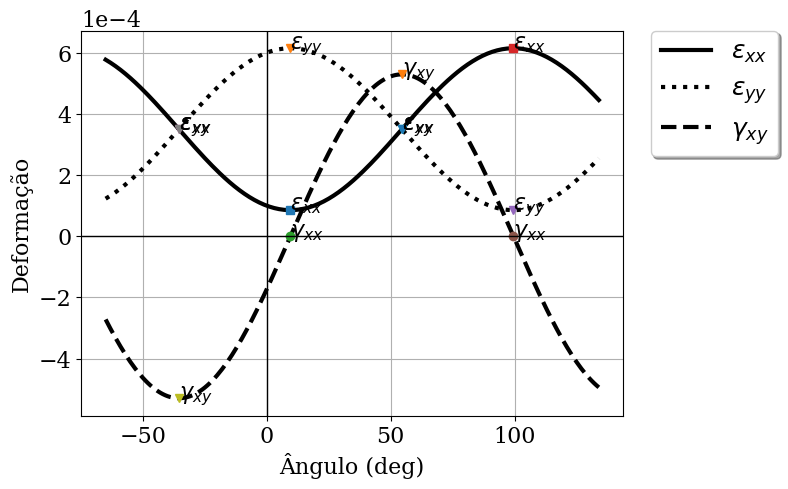

In [21]:
# use LaTeX fonts in the plot
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(tang, extXang, 'k-', label=r'$\varepsilon_{xx}$', linewidth=3)
ax.plot(tang, extYang, 'k:', label=r'$\varepsilon_{yy}$', linewidth=3)
ax.plot(tang, distang, 'k--', label=r'$\gamma_{xy}$', linewidth=3)

ax.plot(np.rad2deg(aPI), ePIa, 's')
ax.text(np.rad2deg(aPI), ePIa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPI), ePIIa, 'v')
ax.text(np.rad2deg(aPI), ePIIa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPI), dPIa, 'o')
ax.text(np.rad2deg(aPI), dPIa,r'$\gamma_{xx}$')

ax.plot(np.rad2deg(aPII), ePIb, 's')
ax.text(np.rad2deg(aPII), ePIb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPII), ePIIb, 'v')
ax.text(np.rad2deg(aPII), ePIIb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPII), dPIb, 'o')
ax.text(np.rad2deg(aPII), dPIb,r'$\gamma_{xx}$')

ax.plot(np.rad2deg(corteAngPI), epsx1ShearPa, 'v')
ax.text(np.rad2deg(corteAngPI), epsx1ShearPa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngPI), epsy1ShearPa, 'v')
ax.text(np.rad2deg(corteAngPI), epsy1ShearPa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngPI), cortePa, 'v')
ax.text(np.rad2deg(corteAngPI), cortePa,r'$\gamma_{xy}$')

ax.plot(np.rad2deg(corteAngPII), epsx1ShearPb, 'v')
ax.text(np.rad2deg(corteAngPII), epsx1ShearPb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngPII), epsy1ShearPb, 'v')
ax.text(np.rad2deg(corteAngPII), epsy1ShearPb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngPII), cortePb, 'v')
ax.text(np.rad2deg(corteAngPII), cortePb,r'$\gamma_{xy}$')

plt.ticklabel_format(axis='y',style='sci',scilimits=(1,4))
ax.set(xlabel='Ângulo (deg)', ylabel='Deformação')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()


PLANO x-y:
  Deformação normal mínima:  85.425
  Deformação normal máxima:  614.575
  Deformação normal média :  350.0
Deformação de corte mínima:  -264.575
Deformação de corte máxima:  264.575
Ponto A ( 100.0 , 86.6 )
Ponto B ( 600.0 , -86.6 )


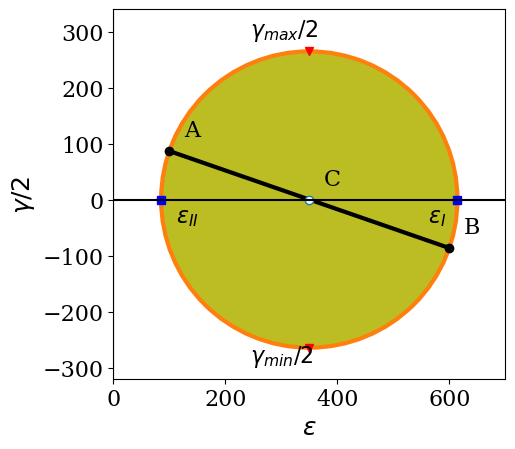

In [22]:
import matplotlib.colors as mcolors

def mohr(E,limits):
    """Plot Mohr circle for a 2D tensor"""
    E11 = E[0][0]
    E12 = E[0][1]
    E22 = E[1][1]
    center = [(E11 + E22)/2.0, 0.0]
    radius = np.sqrt((E11 - E22)**2/4.0 + E12**2)
    Emin = center[0] - radius
    Emax = center[0] + radius

    print("  Deformação normal mínima: ", np.round(Emin,3))
    print("  Deformação normal máxima: ", np.round(Emax, 3))
    print("  Deformação normal média : ", np.round(center[0], 3))
    print("Deformação de corte mínima: ", np.round(-radius, 3))
    print("Deformação de corte máxima: ", np.round(radius, 3))

    print('Ponto A (','{:.1f}'.format(E11),',','{:.1f}'.format(-E12),')')
    print('Ponto B (','{:.1f}'.format(E22),',','{:.1f}'.format(E12),')')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3, edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Emin - .3*radius, Emax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([E11, E22], [-E12, E12], 'ko', linewidth=3)
    plt.plot([E11, E22], [-E12, E12], 'k', linewidth=3)
    plt.plot(Emin, 0, 'bs')
    plt.plot(Emax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(E11 + desv, -E12 + desv , 'A')
    plt.text(E22 + desv, E12 + desv, 'B')
    plt.text(Emin + .1*radius, -0.15*radius, r'$\varepsilon_{II}$')
    plt.text(Emax - .2*radius, -0.15*radius, r'$\varepsilon_{I}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\gamma_{max}/2$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\gamma_{min}/2$')
    plt.xlabel(r'$\varepsilon$', size=18)
    plt.ylabel(r'$\gamma/2$', size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[0,700],[-320,340]])
print('\n================================')
print('PLANO x-y:')
print('================================')
exx = matDef[0,0]
eyy = matDef[1,1]
exy = matDef[0,1]
E1 = np.array([[exx, exy],[exy, eyy]])
mohr(E1, axislim)

### Apêndice A. Deformações principais

As deformações principais para um elemento plano de deformação representam as extensões máxima e minima que ocurrem num determinado ponto material do objeto.
Genericamente, estes valores podem ser obtidos usando expressões de transformação do tensor das deformações ou recorrendo ao método da circunferência de Mohr. Concretamente podem ser obtidas resolvendo:

\begin{equation*}
\det(\varepsilon_{ij}-\epsilon\delta_{ij}) = 0
\end{equation*}

A solução desta equação conduz a um polinómio cúbico na forma:

\begin{equation*}
\epsilon^3 - J_1 \epsilon^2 + J_2 \epsilon - J_3 = 0
\end{equation*}

em que $J_\alpha~,  \alpha=1,2,3$ são os invariantes da matriz do tensor das deformações, assim definidos:

\begin{equation*}
\begin{aligned}
J_1 & = \varepsilon_{xx} + \varepsilon_{yy} + \varepsilon_{zz}\\
J_2 & = \varepsilon_{xx}\varepsilon_{yy} +
\varepsilon_{yy}\varepsilon_{zz} +
\varepsilon_{zz}\varepsilon_{xx} -
\frac{\gamma_{xy}^2}{4} -
\frac{\gamma_{yz}^2}{4} -
\frac{\gamma_{zx}^2}{4}\\
 J_3 & = \varepsilon_{xx}\varepsilon_{yy}\varepsilon_{zz}-
 \frac{\varepsilon_{xx}\gamma_{yz}^2}{4} -
 \frac{\varepsilon_{yy}\gamma_{zx}^2}{4}-
 \frac{\varepsilon_{zz}\gamma_{xy}^2}{4}+
 \frac{\gamma_{xy}\gamma_{yz}\gamma_{yz}}{4}
\end{aligned}
\end{equation*}

A solução da equação caraterística para as deformações principais pode conter três situações plausíveis:

- $\epsilon_\mathrm{I} \ne \epsilon_\mathrm{II} \ne \epsilon_\mathrm{III}$
- $\epsilon_\mathrm{I} = \epsilon_\mathrm{II} \ne \epsilon_\mathrm{III}$
- $\epsilon_\mathrm{I} = \epsilon_\mathrm{II} = \epsilon_\mathrm{III}$


### Apêndice B. A convenção de sinal para a dirtorção de corte

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P001_i3.jpg"
width="400" height="370">


### Apêndice C. Deformação de corte de engenharia ($\gamma_{ij}$) versus deformação de corte tensorial ($\varepsilon_{ij}$)

Num determinado ponto material, $O$, considerem-se dois segmentos de reta infinitésimais $\overline{OP}$ e $\overline{OQ}$ com comprimentos iniciais $dS_1$ e $dS_2$ respetivamente. Sejam $(l_1,m_1,n_1)$ e $(l_2,m_2,n_2)$ os cossenos diretores dos versores que definem as direções dos segmentos elementares $\overline{OP}$ e $\overline{OQ}$, respetivamente. Na configuração inicial, assuma-se que estes segmentos formam um ângulo reto entre si, tal que o seu produto escalar é nulo: $\vec{OP}\cdot\vec{OQ} = \cos(\vec{OP},\vec{OQ}) \equiv \cos\theta = l_1l_2 + m_1m_2 + n_1n_2 = 0$. Após deformação do corpo, os pontos materiais $O$, $P$ e $Q$, ocuparão novas posições no espaço $o$, $p$ e $q$, de acordo com o campo de deslocamentos aplicados $\vec{r}^* = \vec{R} + \vec{u}(x,y,z)$. Os novos segmentos $\overline{op}$ e $\overline{oq}$, na configuração atual, estarão orientados em direções cujos versores no referencial escolhido são $(l_1^*,m_1^*,n_1^*)$ e $(l_2^*,m_2^*,n_2^*)$, respetivamente. O novo ângulo $\theta^*$ formado entre os sementos na configuração atual pode ser definido por: $\vec{op}\cdot\vec{oq}=\cos(\vec{oq},\vec{oq})\equiv\cos\theta^*=l_1^*l_2^*+m_1^*m_2^*+n_1^*n_2^*$. É possível mostrar (Ref. [1]) que a distorção angular de engenharia ($\gamma_{12}$) pode ser definida de acordo com a seguinte expressão:

\begin{equation*}
\begin{aligned}
\gamma_{12} &= (1+\varepsilon_{\textrm{OP}})(1+\varepsilon_{\textrm{OQ}})\cos\theta^* \\
&= 2l_1l_2\varepsilon_{xx} + 2m_1m_2\varepsilon_{yy} + 2n_1n_2\varepsilon_{zz}
+ 2(l_1m_2 + l_2m_1)\varepsilon_{xy} + 2(m_1n_2 + m_2n_1)\varepsilon_{yz}
+ 2(l_1n_2 + l_2n_1)\varepsilon_{xz}\\
\end{aligned}
\end{equation*}

em que $\varepsilon_{ij}$ são as componentes cartesianas do tensor das deformações no sistema de coordenadas escolhido. Para encontrar uma interpretação física para a dirtorção angular do tensor de deformações $\varepsilon_{xy}$, assuma-se, sem perda de generalidade, que as direções dos segmentos infinitésimais $\overline{OP}$ e $\overline{OR}$ são paralelos aos eixos $x$ e $y$, ou seja: $l_1=1; m_1=n_1=0$ e $m_2=1; l_2=n_2=0$. Desta forma obtêm-se da expressão anterior:

\begin{equation*}
\begin{aligned}
\gamma_{12} &\equiv \gamma_{xy} = 2\varepsilon_{xy} \\
\end{aligned}
\end{equation*}

O mesmo sendo válido para os restantes pares de eixos coordenados pelo que: $\gamma_{yz} = 2\varepsilon_{yz}$ e $\gamma_{xz} = 2\varepsilon_{xz}$

Para pequenas deformações mostra-se aida que é válida a seguinte aproximação:

\begin{equation*}
\begin{aligned}
\gamma_{12} &= (1+\varepsilon_{PQ})(1+\varepsilon_{PR})\cos\theta^*
\approx \frac{\pi}{2} - \theta^*\\
\end{aligned}
\end{equation*}



### Bibliografia

[1] Arthur P. Boresi, Richard J. Schmidt. Advanced Mechanics of Materials. 6th Edition, Wiley, 2003.

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
